In [1]:
"""
=============================================================================
01_rag_ablasi_stability_pipeline.py
RAG PIPELINE — CHROMADB INDEXING + ABLASI HYPERPARAMETER + STABILITY TEST
=============================================================================
Thesis : Evaluasi Komparatif Metode Klasifikasi Pendekatan LLM
         pada Data Keselamatan Industri
Penulis: Riza Rahmah Angelia | NRP: M0501241008 | IPB University
=============================================================================
 
PREREQUISITE:
  Jalankan 00_pipeline_eda_preprocessing.py terlebih dahulu.
  File yang dibutuhkan (output pipeline sebelumnya):
    • split_knowledge_base.csv   → 631 baris, Knowledge Base RAG
    • split_test_set.csv         → 71 baris, Test Set FIXED
    • rag_knowledge_docs.json    → 28 dokumen TBC Berau Coal (definisi + severity)
 
ALUR PIPELINE — PENDEKATAN C:
  ┌────────────────────────────────────────────────────────────────┐
  │  TAHAP 0 → Import & Konfigurasi                               │
  │  TAHAP 1 → Build ChromaDB Index                               │
  │             KB data historis + injeksi TBC knowledge docs     │
  │             Import cache run sebelumnya (jika ada)            │
  │                                                                │
  │  TAHAP 2 — Ablasi Grid 1x (15 kombinasi K×T)                 │
  │    K = 1, 3, 5, 7, 9   ×   T = 0.1, 0.3, 0.5               │
  │    Metrik seleksi: F1-Macro                                    │
  │    → Pilih TOP-3 konfigurasi terbaik                          │
  │                                                                │
  │  [OPSIONAL] Ablasi OFAT — Sensitivity Analysis               │
  │    Jalankan via flag RUN_OFAT=True untuk analisis tambahan    │
  │    Bukan bagian alur utama Pendekatan C                       │
  │                                                                │
  │  TAHAP 3 — Stability Test 3x run (hanya TOP-3)               │
  │    Masing-masing kandidat dirun 3x dengan parameter identik   │
  │    → Hitung κ Stability per kandidat                          │
  │                                                                │
  │  TAHAP 4 — Seleksi Final                                      │
  │    Skor gabungan = F1-Macro × 0.6 + κ Stability × 0.4        │
  │    → Konfigurasi dengan skor tertinggi = KONFIGURASI FINAL    │
  │                                                                │
  │  TAHAP 5 — Uji Kestabilan Final (5x run)                      │
  │    Run 5x dengan konfigurasi terpilih (parameter identik)     │
  │    → κ Reliability + κ Stability resmi untuk thesis           │
  │                                                                │
  │  TAHAP 6 — Visualisasi & Ekspor                               │
  └────────────────────────────────────────────────────────────────┘
 
ARSITEKTUR RAG:
  Embedding  : all-MiniLM-L6-v2 (lokal, gratis)
  LLM        : google/flan-t5-large (lokal, gratis, ~5 det/prediksi CPU)
  Vector DB  : ChromaDB (persistent, cosine similarity)
  Knowledge  : split_knowledge_base.csv + rag_knowledge_docs.json (TBC Berau Coal)
  Prompt     : Few-shot — contoh data historis + definisi TBC + severity clue
 
RUANG PENCARIAN HYPERPARAMETER:
  TOP_K : [1, 3, 5, 7, 9]   — jumlah dokumen retrieved dari ChromaDB
  TEMP  : [0.1, 0.3, 0.5]   — temperature LLM generation
  Total : 15 kombinasi
 
EFISIENSI vs PENDEKATAN B:
  Pendekatan B : 15 × 5 × 71 = 5.325 prediksi  (~7.5 jam CPU)
  Pendekatan C : 15×1 + 3×3 + 1×5 = 29 run × 71 = 2.059 prediksi (~2.9 jam)
  Penghematan  : ~61% lebih efisien
 
CACHE OTOMATIS:
  Setiap run disimpan ke output_rag/run_cache.json.
  Jika proses terhenti, jalankan ulang — run yang sudah selesai di-skip.
  Hasil dari notebook sebelumnya (RAG_detail_per_run.xlsx) juga
  diimpor otomatis ke cache saat startup.
 
ESTIMASI WAKTU (CPU, flan-t5-large, ~5 det/prediksi, 71 test):
  Tahap 2 ablasi grid : 15 konfigurasi × 71 × 5s ≈  89 menit
                        (dikurangi cache yang sudah ada)
  Tahap 3 stability   :  3 kandidat × 3 run × 71 × 5s ≈  53 menit
  Tahap 5 final run   :  1 × 5 run × 71 × 5s ≈  30 menit
  Total estimasi       :  ~2.9 jam  (vs ~7.5 jam Pendekatan B)
 
INSTALASI:
=============================================================================
"""
#!pip install sentence-transformers chromadb transformers torch
#!pip install scikit-learn pandas numpy matplotlib seaborn tqdm openpyxl 

'\n=============================================================================\n01_rag_ablasi_stability_pipeline.py\nRAG PIPELINE — CHROMADB INDEXING + ABLASI HYPERPARAMETER + STABILITY TEST\n=============================================================================\nThesis : Evaluasi Komparatif Metode Klasifikasi Pendekatan LLM\n         pada Data Keselamatan Industri\nPenulis: Riza Rahmah Angelia | NRP: M0501241008 | IPB University\n=============================================================================\n\nPREREQUISITE:\n  Jalankan 00_pipeline_eda_preprocessing.py terlebih dahulu.\n  File yang dibutuhkan (output pipeline sebelumnya):\n    • split_knowledge_base.csv   → 631 baris, Knowledge Base RAG\n    • split_test_set.csv         → 71 baris, Test Set FIXED\n    • rag_knowledge_docs.json    → 28 dokumen TBC Berau Coal (definisi + severity)\n\nALUR PIPELINE — PENDEKATAN C:\n  ┌────────────────────────────────────────────────────────────────┐\n  │  TAHAP 0 → Import & Konfig

In [2]:
# =============================================================================
# TAHAP 0: IMPORT & KONFIGURASI
# =============================================================================
import os
import json
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import Counter
from itertools import combinations, product
from datetime import datetime
from tqdm import tqdm
 
from sentence_transformers import SentenceTransformer
import chromadb
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score,
    confusion_matrix, classification_report,
)
 
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor"  : "#f8f9fa",
    "axes.grid"       : True,
    "grid.alpha"      : 0.4,
    "font.family"     : "sans-serif",
    "font.size"       : 11,
})
 
# ── Path input (output dari 00_pipeline_eda_preprocessing.py) ──────────────
KB_PATH        = "split_knowledge_base.csv"
TEST_PATH      = "split_test_set.csv"
KNOWLEDGE_FILE = "rag_knowledge_docs.json"   # 28 dok TBC Berau Coal
 
# ── Path output ─────────────────────────────────────────────────────────────
OUTPUT_DIR  = "output_rag"
CHROMA_DIR  = "chroma_db_rag"
CACHE_FILE  = f"{OUTPUT_DIR}/run_cache.json"
 
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# ── Model ────────────────────────────────────────────────────────────────────
EMBED_MODEL       = "all-MiniLM-L6-v2"
LLM_MODEL         = "google/flan-t5-large"
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SOURCE_LENGTH = 1024
MAX_TARGET_LENGTH = 64
 
# ── Kolom dari pipeline preprocessing ────────────────────────────────────────
COL_LABEL = "label"
COL_TEXT  = "teks_final"
 
# ── Ruang pencarian hyperparameter ───────────────────────────────────────────
KANDIDAT_K  = [1, 3, 5, 7, 9]
KANDIDAT_T  = [0.1, 0.3, 0.5]
TEXT_TRUNC  = 300   # potong teks contoh di prompt (dikunci, tidak diablasi)
 
# Desain OFAT untuk Sensitivity Analysis (OPSIONAL — bukan alur utama Pendekatan C)
# Set RUN_OFAT = True jika ingin menjalankan analisis sensitivitas tambahan
RUN_OFAT     = False
OFAT_FIXED_T = 0.1   # temperature dikunci saat ablasi K (jika RUN_OFAT=True)
 
# ── Seleksi & stability ───────────────────────────────────────────────────────
TOP_N_KANDIDAT   = 3    # ambil top-3 dari ablasi grid untuk stability test
N_STABILITY_RUNS = 3    # jumlah run per kandidat di stability test (Tahap 3)
N_FINAL_RUNS     = 5    # jumlah run di uji kestabilan final (Tahap 5)
W_F1M            = 0.6  # bobot F1-Macro dalam skor gabungan
W_KAPPA          = 0.4  # bobot κ Stability dalam skor gabungan
 
# ── Catatan: Tidak ada RANDOM_SEED di pipeline ini ───────────────────────────
# Split KB/Test sudah dilakukan di 00_pipeline_eda_preprocessing.py (random_state=42)
# dan hasilnya dibaca langsung dari file CSV — tidak ada split ulang di sini.
#
# Satu-satunya sumber randomness adalah do_sample=True pada model.generate(),
# yang SENGAJA dibiarkan stokastik agar κ Stability mengukur variasi nyata
# antar run. Jika di-seed (torch.manual_seed), setiap run akan identik dan
# κ Stability selalu = 1.0 — stability test kehilangan maknanya.
 
print("  RAG PIPELINE — ABLASI + STABILITY TEST")
print(f"  LLM       : {LLM_MODEL}")
print(f"  Embedding : {EMBED_MODEL}")
print(f"  Device    : {DEVICE}")
print(f"  Ruang K   : {KANDIDAT_K}")
print(f"  Ruang T   : {KANDIDAT_T}")
print(f"  Total komb: {len(KANDIDAT_K) * len(KANDIDAT_T)}")

  RAG PIPELINE — ABLASI + STABILITY TEST
  LLM       : google/flan-t5-large
  Embedding : all-MiniLM-L6-v2
  Device    : cpu
  Ruang K   : [1, 3, 5, 7, 9]
  Ruang T   : [0.1, 0.3, 0.5]
  Total komb: 15


In [3]:
# =============================================================================
# TAHAP 1: BUILD CHROMADB INDEX
# =============================================================================
print("TAHAP 1: BUILD CHROMADB INDEX")
 
# ── 1a. Load data dari pipeline sebelumnya ────────────────────────────────────
df_kb   = pd.read_csv(KB_PATH)
df_test = pd.read_csv(TEST_PATH)
 
df_kb[COL_TEXT]   = df_kb[COL_TEXT].fillna("").astype(str)
df_test[COL_TEXT] = df_test[COL_TEXT].fillna("").astype(str)
df_kb[COL_LABEL]  = df_kb[COL_LABEL].astype(str).str.strip()
df_test[COL_LABEL] = df_test[COL_LABEL].astype(str).str.strip()
 
all_labels   = sorted(pd.concat([df_kb[COL_LABEL], df_test[COL_LABEL]]).unique())
GROUND_TRUTH = df_test[COL_LABEL].tolist()
N_TEST       = len(df_test)
 
print(f"\n✔ KB    : {len(df_kb)} dokumen  |  Test : {N_TEST} dokumen")
print(f"✔ Kelas : {len(all_labels)}")
print(f"\nDistribusi Test Set:")
for lbl, cnt in df_test[COL_LABEL].value_counts().items():
    print(f"  {cnt:>3}  {lbl}")
 
# ── 1b. Init embedding model ──────────────────────────────────────────────────
print(f"\nMemuat embedding model: {EMBED_MODEL}...")
embedder = SentenceTransformer(EMBED_MODEL)
 
# ── 1c. Setup ChromaDB collection ────────────────────────────────────────────
chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)
COLLECTION_NAME = "kb_rag_enriched"   # nama baru karena ada injeksi TBC knowledge
 
try:
    collection = chroma_client.get_collection(COLLECTION_NAME)
    print(f"\n✔ Reuse collection '{COLLECTION_NAME}' ({collection.count()} dokumen)")
    _collection_exists = True
except Exception:
    _collection_exists = False
 
if not _collection_exists:
    print(f"\nMembuat collection baru '{COLLECTION_NAME}'...")
    try:
        chroma_client.delete_collection(COLLECTION_NAME)
    except Exception:
        pass
 
    collection = chroma_client.create_collection(
        COLLECTION_NAME,
        metadata={"hnsw:space": "cosine"}
    )
 
    # ── Index KB data (tipe "example") ───────────────────────────────────────
    print(f"  Mengindeks {len(df_kb)} dokumen KB data historis...")
    kb_texts      = df_kb[COL_TEXT].tolist()
    kb_embeddings = embedder.encode(
        kb_texts, batch_size=64, show_progress_bar=True,
        normalize_embeddings=True
    )
    kb_metadatas = [
        {
            "label" : row[COL_LABEL],
            "type"  : "example",          # ← tipe: data historis
            "text"  : row[COL_TEXT][:TEXT_TRUNC],
        }
        for _, row in df_kb.iterrows()
    ]
    collection.add(
        ids        = [f"kb_{i}" for i in range(len(kb_texts))],
        embeddings = kb_embeddings.tolist(),
        metadatas  = kb_metadatas,
    )
    print(f"  ✔ {collection.count()} dokumen KB terindeks")
 
    # ── Injeksi TBC knowledge docs (tipe "definition" & "keywords_severity") ──
    print(f"\n  Menginjeksi TBC knowledge documents dari {KNOWLEDGE_FILE}...")
    if not os.path.exists(KNOWLEDGE_FILE):
        print(f"  ⚠ File {KNOWLEDGE_FILE} tidak ditemukan — skip injeksi TBC knowledge")
        print(f"     Pastikan file ada di direktori yang sama dengan script ini")
    else:
        with open(KNOWLEDGE_FILE, encoding="utf-8") as f:
            tbc_docs = json.load(f)
 
        # Cek duplikat (jaga-jaga jika dijalankan ulang)
        existing_ids = set(collection.get(include=[])["ids"])
        new_tbc_docs = [d for d in tbc_docs if d["doc_id"] not in existing_ids]
 
        if new_tbc_docs:
            tbc_texts      = [d["text"] for d in new_tbc_docs]
            tbc_embeddings = embedder.encode(
                tbc_texts, batch_size=32, show_progress_bar=True,
                normalize_embeddings=True
            )
            tbc_metadatas = [
                {
                    "label"   : d["label"],
                    "type"    : d["type"],        # "definition" atau "keywords_severity"
                    "severity": d["severity"],
                    "text"    : d["text"][:400],
                }
                for d in new_tbc_docs
            ]
            collection.add(
                ids        = [d["doc_id"] for d in new_tbc_docs],
                embeddings = tbc_embeddings.tolist(),
                metadatas  = tbc_metadatas,
            )
            print(f"  ✔ {len(new_tbc_docs)} TBC knowledge docs terinjeksi")
        else:
            print(f"  ✔ TBC knowledge docs sudah ada sebelumnya")
 
    print(f"\n✔ Total dokumen di collection: {collection.count()}")
    print(f"  Breakdown:")
    print(f"    KB data historis (example)        : {len(df_kb)}")
    print(f"    TBC knowledge docs (def + kw_sev) : {len(tbc_docs) if os.path.exists(KNOWLEDGE_FILE) else 0}")
 
# ── 1d. Pre-encode test set (sekali, dipakai semua run) ──────────────────────
print(f"\nEncoding {N_TEST} dokumen test set...")
test_texts      = df_test[COL_TEXT].tolist()
test_embeddings = embedder.encode(
    test_texts, batch_size=64, show_progress_bar=True,
    normalize_embeddings=True
)
print("✔ Test set encoded")
 
# ── Bangun variabel global untuk prompt (dari tbc_docs) ────────────────────
# Pastikan tbc_docs tersedia; load ulang jika perlu
if 'tbc_docs' not in dir() or tbc_docs is None:
    with open(KNOWLEDGE_FILE, encoding='utf-8') as _f:
        tbc_docs = json.load(_f)
 
_defs_by_label = {d['label']: d['text'] for d in tbc_docs if d['type'] == 'definition'}
_kw_by_label   = {d['label']: d['text'] for d in tbc_docs if d['type'] == 'keywords_severity'}
 
MANUAL_RULES_STR      = '\n\n'.join(_defs_by_label[l] for l in sorted(_defs_by_label))
CATEGORY_KEYWORDS_STR = '\n\n'.join(_kw_by_label[l]   for l in sorted(_kw_by_label))
VALID_CATEGORIES_STR  = '\n'.join(f'- {l}' for l in all_labels)
 
print(f'\n✔ MANUAL_RULES_STR      : {len(MANUAL_RULES_STR)} karakter ({len(_defs_by_label)} kategori)')
print(f'✔ CATEGORY_KEYWORDS_STR : {len(CATEGORY_KEYWORDS_STR)} karakter ({len(_kw_by_label)} kategori)')
print(f'✔ VALID_CATEGORIES_STR  : {len(all_labels)} kategori')
 
 
 
# =============================================================================
# FUNGSI INTI (dipakai di semua tahap)
# =============================================================================
 
def build_prompt(query_text: str, retrieved_docs: list) -> str:
    """
    Bangun prompt few-shot dengan template baru:
      - {manual_rules}          : definisi kategori dari tbc_docs (statis, global)
      - {category_keywords}     : pemetaan kata kunci per kategori (statis, global)
      - {referensi_dinamis_rag} : contoh historis yang di-retrieve ChromaDB (dinamis)
      - {deskripsi_input}       : teks laporan yang diklasifikasi
 
    Variabel global yang dibutuhkan (dibangun di TAHAP 1):
      MANUAL_RULES_STR      - gabungan teks semua definition docs
      CATEGORY_KEYWORDS_STR - gabungan teks semua keywords_severity docs
      VALID_CATEGORIES_STR  - daftar label valid (satu per baris)
    """
    # Bagian dinamis: contoh historis dari ChromaDB
    examples = [d for d in retrieved_docs if d.get('type') == 'example']
    if examples:
        referensi_lines = [
            f'Contoh {i}:\nTeks: {ex["text"][:TEXT_TRUNC]}\nKategori: {ex["label"]}'
            for i, ex in enumerate(examples, 1)
        ]
        referensi_dinamis = '\n\n'.join(referensi_lines)
    else:
        referensi_dinamis = '(tidak ada contoh historis tersedia)'
 
    prompt = (
        'Anda adalah Ahli Evaluator Keselamatan K3 Pertambangan. '
        'Tugas Anda adalah mengklasifikasikan laporan bahaya (hazard) ke dalam '
        'SATU kategori yang paling tepat berdasarkan standar baku.\n\n'
        f'<aturan_standar>\n{MANUAL_RULES_STR}\n</aturan_standar>\n\n'
        f'<pemetaan_kata_kunci>\n{CATEGORY_KEYWORDS_STR}\n</pemetaan_kata_kunci>\n\n'
        f'<referensi_historis>\n{referensi_dinamis}\n</referensi_historis>\n\n'
        f'<daftar_kategori_valid>\n{VALID_CATEGORIES_STR}\n</daftar_kategori_valid>\n\n'
        'INSTRUKSI OUTPUT:\n'
        '1. Evaluasi teks laporan bahaya di bawah ini menggunakan aturan dan referensi historis yang tersedia.\n'
        '2. Klasifikasikan ke dalam salah satu kategori dari <daftar_kategori_valid>.\n'
        '3. Jawab HANYA dengan nama kategori yang valid tanpa tambahan teks, tanda baca, atau penjelasan apa pun.\n'
        'Contoh jawaban benar: 7. LOTO\n\n'
        f'<laporan_bahaya>\n{query_text}\n</laporan_bahaya>'
    )
    return prompt
 
 
def parse_label(raw: str, labels: list, fallback: str) -> str:
    """Cocokkan output LLM ke label yang valid — pilih substring terpanjang."""
    raw_lower = raw.lower().strip()
    best, best_len = None, 0
    for lbl in labels:
        if lbl.lower() in raw_lower and len(lbl) > best_len:
            best_len = len(lbl)
            best     = lbl
    return best if best else fallback
 
 
def compute_metrics(y_true: list, y_pred: list) -> dict:
    """Hitung semua metrik klasifikasi untuk satu run."""
    return {
        "accuracy"    : round(accuracy_score(y_true, y_pred), 4),
        "precision_w" : round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "precision_m" : round(precision_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "recall_w"    : round(recall_score(   y_true, y_pred, average="weighted", zero_division=0), 4),
        "recall_m"    : round(recall_score(   y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_w"        : round(f1_score(       y_true, y_pred, average="weighted", zero_division=0), 4),
        "f1_m"        : round(f1_score(       y_true, y_pred, average="macro",    zero_division=0), 4),
    }
 
 
def majority_vote(all_preds: list) -> list:
    """Majority vote dari beberapa run."""
    return [Counter([r[i] for r in all_preds]).most_common(1)[0][0]
            for i in range(len(all_preds[0]))]
 
 
def interpret_kappa(k: float) -> str:
    if k >= 0.80: return "Sangat Kuat"
    if k >= 0.60: return "Kuat"
    if k >= 0.40: return "Sedang"
    if k >= 0.20: return "Lemah"
    return "Sangat Lemah"
 
 
# Cache global
cache: dict = {}
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        cache = json.load(f)
    print(f"\n✔ Cache dimuat: {len(cache)} run tersimpan")
 
# ── Import cache dari notebook sebelumnya (RAG_detail_per_run.xlsx) ──────────
# Jika ada hasil run sebelumnya, konversi ke format cache agar tidak di-rerun
PREV_RESULT_FILE = "RAG_detail_per_run.xlsx"
if os.path.exists(PREV_RESULT_FILE):
    print(f"\n✔ Ditemukan hasil sebelumnya: {PREV_RESULT_FILE}")
    try:
        df_prev = pd.read_excel(PREV_RESULT_FILE)
        # Ekspektasi kolom: run, top_k, temperature, test_idx, pred_label
        required_prev_cols = {"run", "top_k", "temperature", "test_idx", "pred_label"}
        if required_prev_cols.issubset(df_prev.columns):
            imported = 0
            for (run_n, k, t), grp in df_prev.groupby(["run", "top_k", "temperature"]):
                grp_sorted = grp.sort_values("test_idx")
                cache_key  = f"K{k}_T{t}_prev_r{int(run_n)}"
                if cache_key not in cache:
                    cache[cache_key] = grp_sorted["pred_label"].tolist()
                    imported += 1
            if imported > 0:
                save_cache()
                print(f"  ✔ {imported} run diimpor dari {PREV_RESULT_FILE} ke cache")
            else:
                print(f"  ✔ Semua run dari {PREV_RESULT_FILE} sudah ada di cache")
        else:
            missing_c = required_prev_cols - set(df_prev.columns)
            print(f"  ⚠ Kolom tidak sesuai, skip import: {missing_c}")
    except Exception as e:
        print(f"  ⚠ Gagal membaca {PREV_RESULT_FILE}: {e}")
else:
    print(f"  ℹ {PREV_RESULT_FILE} tidak ditemukan — memulai dari awal")
 
 
def save_cache():
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, ensure_ascii=False)
 
 
def run_single(top_k: int, temperature: float,
               tokenizer, model, run_id: str = "") -> list:
    """
    Inferensi satu run (N_TEST prediksi) dengan konfigurasi (top_k, temperature).
 
    Retrieval menarik campuran:
      - Dokumen 'example' (data historis KB)
      - Dokumen 'definition' dan 'keywords_severity' (TBC knowledge Berau Coal)
    LLM memproses prompt gabungan dan menghasilkan label.
    """
    cache_key = f"K{top_k}_T{temperature}_{run_id}"
    if cache_key in cache:
        return cache[cache_key]
 
    preds = []
    for query_text, query_emb in tqdm(
        zip(test_texts, test_embeddings),
        total=N_TEST,
        desc=f"  K={top_k} T={temperature} [{run_id}]",
        ncols=72,
    ):
        # ── Retrieve: ambil top_k dokumen (campuran semua tipe) ──────────────
        results = collection.query(
            query_embeddings=[query_emb.tolist()],
            n_results=top_k,
        )
        retrieved_docs  = []
        neighbor_labels = []
        for j in range(len(results["metadatas"][0])):
            meta = results["metadatas"][0][j]
            retrieved_docs.append({
                "text"    : meta.get("text", ""),
                "label"   : meta.get("label", ""),
                "type"    : meta.get("type", "example"),
                "severity": meta.get("severity", ""),
            })
            if meta.get("type", "example") == "example":
                neighbor_labels.append(meta["label"])
 
        # Fallback label = label tetangga terdekat yang merupakan example
        fallback = neighbor_labels[0] if neighbor_labels else all_labels[0]
 
        # ── Augment + Generate ────────────────────────────────────────────────
        prompt = build_prompt(query_text, retrieved_docs)
        inputs = tokenizer(
            prompt, return_tensors="pt",
            truncation=True, max_length=MAX_SOURCE_LENGTH,
        ).to(DEVICE)
 
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_TARGET_LENGTH,
                do_sample=True,
                temperature=temperature,
            )
 
        raw  = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
        pred = parse_label(raw, all_labels, fallback)
        preds.append(pred)
 
    cache[cache_key] = preds
    save_cache()
    return preds
 
 
# ── Load LLM ──────────────────────────────────────────────────────────────────
print("\n" + "─" * 65)
print(f"LOAD LLM: {LLM_MODEL}")
print("─" * 65)
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(LLM_MODEL).to(DEVICE)
llm_model.eval()
print(f"✔ Model siap di {DEVICE}")
 
 
# =============================================================================
# [OPSIONAL] ABLASI SENSITIVITY — OFAT
# Bukan bagian alur utama Pendekatan C.
# Aktifkan dengan RUN_OFAT = True di konfigurasi untuk analisis tambahan.
# Hasilnya tidak mempengaruhi Tahap 2 (ablasi grid) ke depan.
# =============================================================================
if RUN_OFAT:
    print("\n" + "═" * 65)
    print("[OPSIONAL] ABLASI SENSITIVITY (OFAT)")
    print(f"  Fase A — Ablasi TOP_K  (T={OFAT_FIXED_T} dikunci): K = {KANDIDAT_K}")
    print("═" * 65)
 
    # ── Fase A: ablasi K ──────────────────────────────────────────────────────
    print("\n── FASE A: ABLASI TOP_K ──")
    ofat_fase_a = []
 
    for k in KANDIDAT_K:
        print(f"\n  TOP_K = {k}  (T={OFAT_FIXED_T})")
        preds   = run_single(k, OFAT_FIXED_T, tokenizer, llm_model, run_id="ofat_k")
        metrics = compute_metrics(GROUND_TRUTH, preds)
        ofat_fase_a.append({"top_k": k, "temperature": OFAT_FIXED_T,
                             "preds": preds, **metrics})
        print(f"    Acc={metrics['accuracy']:.4f}  F1-M={metrics['f1_m']:.4f}  "
              f"F1-W={metrics['f1_w']:.4f}")
 
    ofat_a_df    = pd.DataFrame([{k: v for k, v in r.items() if k != "preds"}
                                  for r in ofat_fase_a])
    BEST_K_OFAT  = int(ofat_a_df.loc[ofat_a_df["f1_m"].idxmax(), "top_k"])
 
    print(f"\n  ✔ K terbaik OFAT: {BEST_K_OFAT}  "
          f"(F1-M={ofat_a_df['f1_m'].max():.4f})")
    print(ofat_a_df[["top_k", "temperature", "accuracy", "f1_m", "f1_w"]].to_string(index=False))
 
    # ── Fase B: ablasi T ──────────────────────────────────────────────────────
    print(f"\n── FASE B: ABLASI TEMPERATURE (K={BEST_K_OFAT} dikunci) ──")
    ofat_fase_b = []
 
    for t in KANDIDAT_T:
        print(f"\n  Temperature = {t}  (K={BEST_K_OFAT})")
        preds   = run_single(BEST_K_OFAT, t, tokenizer, llm_model, run_id="ofat_t")
        metrics = compute_metrics(GROUND_TRUTH, preds)
        ofat_fase_b.append({"top_k": BEST_K_OFAT, "temperature": t,
                             "preds": preds, **metrics})
        print(f"    Acc={metrics['accuracy']:.4f}  F1-M={metrics['f1_m']:.4f}  "
              f"F1-W={metrics['f1_w']:.4f}")
 
    ofat_b_df    = pd.DataFrame([{k: v for k, v in r.items() if k != "preds"}
                                  for r in ofat_fase_b])
    BEST_T_OFAT  = float(ofat_b_df.loc[ofat_b_df["f1_m"].idxmax(), "temperature"])
 
    print(f"\n  ✔ T terbaik OFAT: {BEST_T_OFAT}  "
          f"(F1-M={ofat_b_df['f1_m'].max():.4f})")
    print(f"  ✔ Rekomendasi OFAT: K={BEST_K_OFAT}, T={BEST_T_OFAT}  "
          f"(belum dikonfirmasi stabilitas)")
    print(ofat_b_df[["top_k", "temperature", "accuracy", "f1_m", "f1_w"]].to_string(index=False))
 
    # Simpan hasil OFAT
    pd.concat([
        ofat_a_df[["top_k","temperature","accuracy","f1_m","f1_w","precision_m","recall_m"]],
        ofat_b_df[["top_k","temperature","accuracy","f1_m","f1_w","precision_m","recall_m"]].iloc[
            [i for i, t in enumerate(ofat_b_df["temperature"]) if t != OFAT_FIXED_T]
        ]
    ]).to_excel(f"{OUTPUT_DIR}/OFAT_sensitivity_analysis.xlsx", index=False)
    print(f"  ✔ Hasil disimpan: OFAT_sensitivity_analysis.xlsx")
 
else:
    print("\n[OPSIONAL] Ablasi OFAT dilewati (RUN_OFAT=False)")
    print("  Ubah RUN_OFAT=True di konfigurasi untuk menjalankan sensitivity analysis")
    BEST_K_OFAT = None
    BEST_T_OFAT = None
 

TAHAP 1: BUILD CHROMADB INDEX

✔ KB    : 631 dokumen  |  Test : 71 dokumen
✔ Kelas : 15

Distribusi Test Set:
   61  Non TBC
    4  5. Deviasi Loading/Dumping
    2  4. Posisi Pekerja pada Area Tidak aman/Tidak Sesuai Prosedur
    1  14. Technology
    1  6. Tidak terdapat pengawas/pengawas tidak memadai
    1  11. Bahaya Elektrikal
    1  12. Bahaya Biologis

Memuat embedding model: all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✔ Test set encoded
  ℹ RAG_detail_per_run.xlsx tidak ditemukan — memulai dari awal

─────────────────────────────────────────────────────────────────
LOAD LLM: google/flan-t5-large
─────────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✔ Model siap di cpu

[OPSIONAL] Ablasi OFAT dilewati (RUN_OFAT=False)
  Ubah RUN_OFAT=True di konfigurasi untuk menjalankan sensitivity analysis


TAHAP 2 — ABLASI GRID: 15 kombinasi K×T (1x run per kombinasi)
  Tujuan : temukan Top-3 konfigurasi terbaik berdasarkan F1-Macro

── K=1, T=0.1 ──


  K=1 T=0.1 [grid]: 100%|███████████████| 71/71 [01:28<00:00,  1.25s/it]


   Acc=0.8310  F1-M=0.2394  F1-W=0.8385

── K=1, T=0.3 ──


  K=1 T=0.3 [grid]: 100%|███████████████| 71/71 [01:22<00:00,  1.16s/it]


   Acc=0.8310  F1-M=0.2394  F1-W=0.8385

── K=1, T=0.5 ──


...

   Acc=0.8873  F1-M=0.4671  F1-W=0.8656

── K=9, T=0.3 ──


  K=9 T=0.3 [grid]: 100%|███████████████| 71/71 [03:01<00:00,  2.56s/it]


   Acc=0.8873  F1-M=0.4671  F1-W=0.8656

── K=9, T=0.5 ──


  K=9 T=0.5 [grid]: 100%|███████████████| 71/71 [03:00<00:00,  2.54s/it]


   Acc=0.8873  F1-M=0.4671  F1-W=0.8656

─────────────────────────────────────────────────────────────────
HASIL ABLASI GRID (diurutkan F1-Macro):
 top_k  temperature  accuracy   f1_m   f1_w  precision_m  recall_m
     7          0.3    0.9014 0.4778 0.8766       0.5584    0.4619
     7          0.1    0.9014 0.4778 0.8766       0.5584    0.4619
     5          0.1    0.8873 0.4671 0.8656       0.4868    0.4596
     9          0.1    0.8873 0.4671 0.8656       0.4868    0.4596
     5          0.3    0.8873 0.4671 0.8656       0.4868    0.4596
     9          0.3    0.8873 0.4671 0.8656       0.4868    0.4596
     9          0.5    0.8873 0.4671 0.8656       0.4868    0.4596
     5          0.5    0.8732 0.4659 0.8583       0.4866    0.4573
     7          0.5    0.8873 0.4290 0.8647       0.4868    0.4596
     3          0.3    0.8873 0.3339 0.8562       0.4136    0.3191
     3          0.1    0.8873 0.3339 0.8562       0.4136    0.3191
     3          0.5    0.8873 0.3339 0.8562      

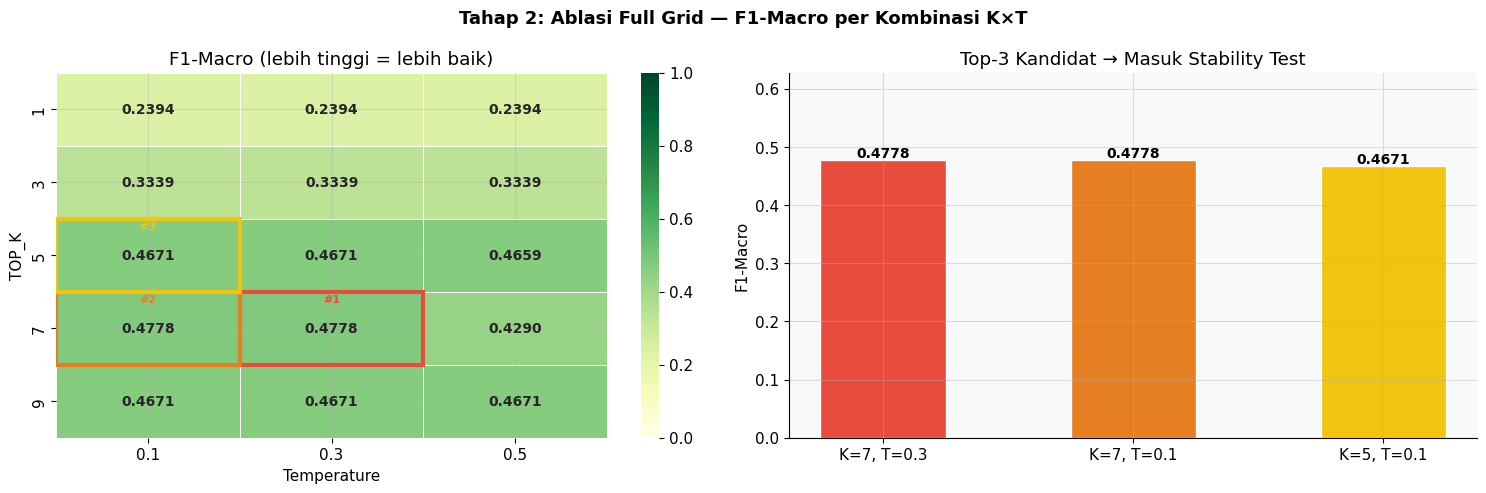

✔ Plot disimpan: T2_ablasi_grid_heatmap_top3.png


In [4]:
# =============================================================================
# TAHAP 2: ABLASI FULL GRID (15 kombinasi K×T, 1x run) → pilih Top-3
# =============================================================================
print("TAHAP 2 — ABLASI GRID: 15 kombinasi K×T (1x run per kombinasi)")
print(f"  Tujuan : temukan Top-{TOP_N_KANDIDAT} konfigurasi terbaik berdasarkan F1-Macro")
 
grid_results = []
 
for k, t in product(KANDIDAT_K, KANDIDAT_T):
    print(f"\n── K={k}, T={t} ──")
    preds   = run_single(k, t, tokenizer, llm_model, run_id="grid")
    metrics = compute_metrics(GROUND_TRUTH, preds)
    grid_results.append({"top_k": k, "temperature": t, "preds": preds, **metrics})
    print(f"   Acc={metrics['accuracy']:.4f}  F1-M={metrics['f1_m']:.4f}  F1-W={metrics['f1_w']:.4f}")
 
grid_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "preds"} for r in grid_results]
).sort_values("f1_m", ascending=False).reset_index(drop=True)
 
print(f"\n{'─'*65}")
print("HASIL ABLASI GRID (diurutkan F1-Macro):")
print(grid_df[["top_k", "temperature", "accuracy", "f1_m", "f1_w",
               "precision_m", "recall_m"]].to_string(index=False))
 
top3_df = grid_df.head(TOP_N_KANDIDAT).reset_index(drop=True)
print(f"\n✔ Top-{TOP_N_KANDIDAT} kandidat untuk stability test:")
for _, row in top3_df.iterrows():
    print(f"   K={int(row['top_k'])}, T={row['temperature']}  →  F1-M={row['f1_m']:.4f}")
 
# ── Heatmap F1-Macro ─────────────────────────────────────────────────────────
pivot = grid_df.pivot_table(index="top_k", columns="temperature", values="f1_m", aggfunc="mean")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Tahap 2: Ablasi Full Grid — F1-Macro per Kombinasi K×T",
             fontsize=13, fontweight="bold")
 
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, linecolor="white", ax=axes[0],
            vmin=0, vmax=1, annot_kws={"size": 10, "weight": "bold"})
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("TOP_K")
axes[0].set_title("F1-Macro (lebih tinggi = lebih baik)")
 
# Tandai top-3
top3_colors = ["#e74c3c", "#e67e22", "#f1c40f"]
for rank, row in top3_df.iterrows():
    k_idx = list(pivot.index).index(int(row["top_k"]))
    t_idx = list(pivot.columns).index(row["temperature"])
    axes[0].add_patch(plt.Rectangle(
        (t_idx, k_idx), 1, 1,
        fill=False, edgecolor=top3_colors[rank], lw=3, zorder=5
    ))
    axes[0].text(t_idx + 0.5, k_idx + 0.15, f"#{rank+1}",
                 ha="center", color=top3_colors[rank],
                 fontsize=8, fontweight="bold")
 
# Bar chart Top-3
configs = [f"K={int(r.top_k)}, T={r.temperature}" for r in top3_df.itertuples()]
bars    = axes[1].bar(configs, top3_df["f1_m"], color=top3_colors,
                      edgecolor="white", width=0.5)
for bar, v in zip(bars, top3_df["f1_m"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, min(1.0, top3_df["f1_m"].max() + 0.15))
axes[1].set_ylabel("F1-Macro")
axes[1].set_title(f"Top-{TOP_N_KANDIDAT} Kandidat → Masuk Stability Test")
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/T2_ablasi_grid_heatmap_top3.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✔ Plot disimpan: T2_ablasi_grid_heatmap_top3.png")


═════════════════════════════════════════════════════════════════
TAHAP 3 — STABILITY TEST: 3x run per Top-3 kandidat
  Tujuan : ukur κ Stability (konsistensi prediksi antar run identik)
  Total prediksi tahap ini: 3 × 3 × 71 = 639
═════════════════════════════════════════════════════════════════

── K=7, T=0.3  (Rank #1) ──
  Run 1: Acc=0.9155  F1-M=0.5170  F1-W=0.8981
  Run 2: Acc=0.9155  F1-M=0.5170  F1-W=0.8981
  Run 3: Acc=0.9014  F1-M=0.4778  F1-W=0.8766

  κ Stability : 0.9363 ± 0.0450  (Sangat Kuat)
  F1-M mean   : 0.5039 ± 0.0185

── K=7, T=0.1  (Rank #2) ──
  Run 1: Acc=0.9014  F1-M=0.4778  F1-W=0.8766
  Run 2: Acc=0.9155  F1-M=0.5170  F1-W=0.8981
  Run 3: Acc=0.9155  F1-M=0.5170  F1-W=0.8981

  κ Stability : 0.9363 ± 0.0450  (Sangat Kuat)
  F1-M mean   : 0.5039 ± 0.0185

── K=5, T=0.1  (Rank #3) ──
  Run 1: Acc=0.8873  F1-M=0.4671  F1-W=0.8656
  Run 2: Acc=0.8873  F1-M=0.4671  F1-W=0.8656
  Run 3: Acc=0.8873  F1-M=0.4671  F1-W=0.8656

  κ Stability : 1.0000 ± 0.0000  (Sanga

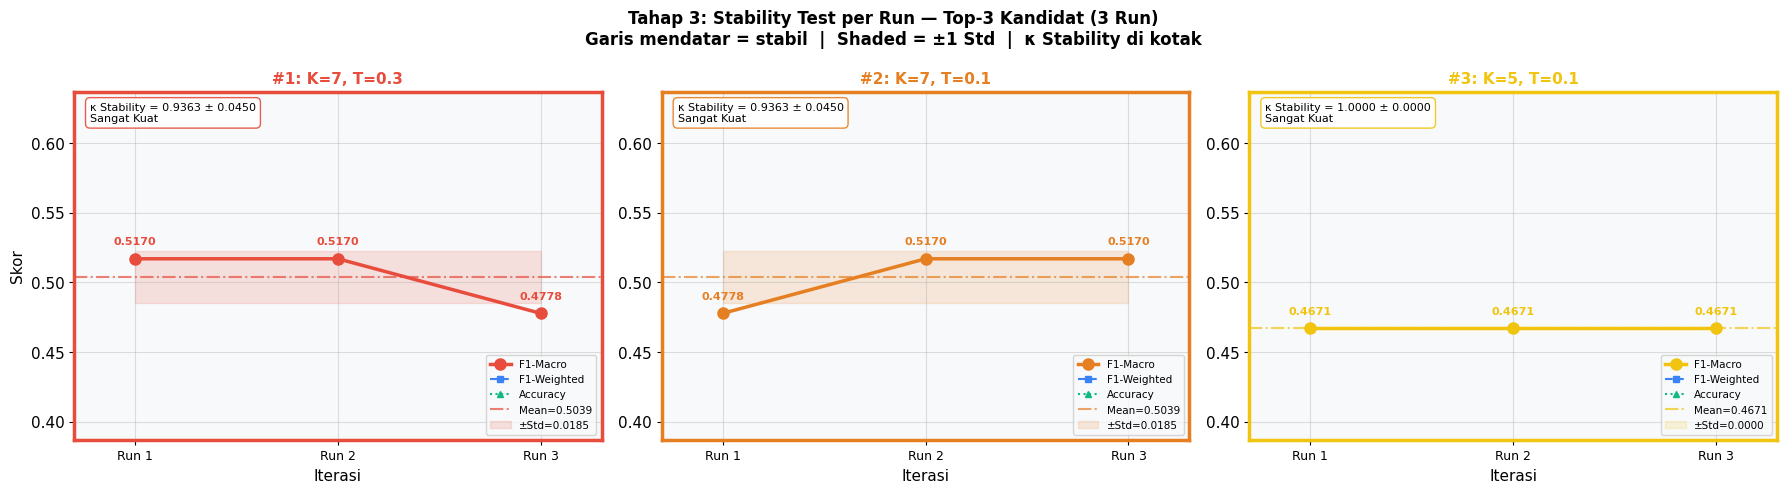

✔ Plot disimpan: T3_stability_top3_per_run.png


In [6]:
# =============================================================================
# TAHAP 3 — STABILITY TEST: 3x run per Top-3 kandidat
# =============================================================================
print("\n" + "═" * 65)
print(f"TAHAP 3 — STABILITY TEST: {N_STABILITY_RUNS}x run per Top-{TOP_N_KANDIDAT} kandidat")
print(f"  Tujuan : ukur κ Stability (konsistensi prediksi antar run identik)")
print(f"  Total prediksi tahap ini: {TOP_N_KANDIDAT} × {N_STABILITY_RUNS} × {N_TEST} = "
      f"{TOP_N_KANDIDAT * N_STABILITY_RUNS * N_TEST}")
print("═" * 65)
 
all_combo_stability = {}
 
for rank, row_t3 in top3_df.iterrows():
    k    = int(row_t3["top_k"])
    t    = row_t3["temperature"]
    cfg  = f"K={k}, T={t}"
    print(f"\n── {cfg}  (Rank #{rank+1}) ──")
 
    run_preds_list   = []
    run_metrics_list = []
 
    for run_n in range(1, N_STABILITY_RUNS + 1):
        preds   = run_single(k, t, tokenizer, llm_model, run_id=f"stab_r{run_n}")
        metrics = compute_metrics(GROUND_TRUTH, preds)
        run_preds_list.append(preds)
        run_metrics_list.append(metrics)
        print(f"  Run {run_n}: Acc={metrics['accuracy']:.4f}  "
              f"F1-M={metrics['f1_m']:.4f}  F1-W={metrics['f1_w']:.4f}")
 
    # κ Stability pairwise antar semua run
    kappa_vals = [
        cohen_kappa_score(run_preds_list[r1], run_preds_list[r2])
        for r1, r2 in combinations(range(N_STABILITY_RUNS), 2)
    ]
    kappa_mean = np.mean(kappa_vals)
    kappa_std  = np.std(kappa_vals)
    f1m_mean   = np.mean([m["f1_m"] for m in run_metrics_list])
    f1m_std    = np.std( [m["f1_m"] for m in run_metrics_list])
 
    print(f"\n  κ Stability : {kappa_mean:.4f} ± {kappa_std:.4f}  ({interpret_kappa(kappa_mean)})")
    print(f"  F1-M mean   : {f1m_mean:.4f} ± {f1m_std:.4f}")
 
    all_combo_stability[cfg] = {
        "top_k"          : k,
        "temperature"    : t,
        "rank_ablasi"    : rank + 1,
        "all_preds"      : run_preds_list,
        "metrics_per_run": run_metrics_list,
        "kappa_stab_mean": round(kappa_mean, 4),
        "kappa_stab_std" : round(kappa_std, 4),
        "kappa_pairs"    : [round(v, 4) for v in kappa_vals],
        "f1m_mean"       : round(f1m_mean, 4),
        "f1m_std"        : round(f1m_std, 4),
    }
 
# ── Visualisasi per-run stability (line chart) ───────────────────────────────
runs_x = list(range(1, N_STABILITY_RUNS + 1))
 
# Kumpulkan Y range global
all_f1m_vals = [
    m["f1_m"]
    for data in all_combo_stability.values()
    for m in data["metrics_per_run"]
]
y_min = max(0,   min(all_f1m_vals) - 0.08)
y_max = min(1.0, max(all_f1m_vals) + 0.12)
 
fig, axes = plt.subplots(1, TOP_N_KANDIDAT, figsize=(6 * TOP_N_KANDIDAT, 5))
fig.suptitle(
    f"Tahap 3: Stability Test per Run — Top-{TOP_N_KANDIDAT} Kandidat ({N_STABILITY_RUNS} Run)\n"
    "Garis mendatar = stabil  |  Shaded = ±1 Std  |  κ Stability di kotak",
    fontsize=12, fontweight="bold"
)

# Definisikan warna default untuk Accuracy jika belum ada di notebook


for idx, (cfg, data) in enumerate(all_combo_stability.items()):
    ax    = axes[idx]
    color = top3_colors[idx]
 
    f1m_r = [m["f1_m"]      for m in data["metrics_per_run"]]
    f1w_r = [m["f1_w"]      for m in data["metrics_per_run"]]
    acc_r = [m["accuracy"]  for m in data["metrics_per_run"]]
 
    ax.plot(runs_x, f1m_r, "o-",  color=color,      lw=2.5, ms=8,  label="F1-Macro",    zorder=5)
    # Definisikan warna F1-Weighted jika belum ada
    COLOR_F1W = globals().get("COLOR_F1W", "#3b82f6")
    COLOR_ACC = globals().get("COLOR_ACC", "#10b981")
    ax.plot(runs_x, f1w_r, "s--", color=COLOR_F1W, lw=1.5, ms=5, label="F1-Weighted")
    ax.plot(runs_x, acc_r, "^:",  color=COLOR_ACC,  lw=1.5, ms=5,  label="Accuracy")
 
    f1m_mean = data["f1m_mean"]
    f1m_std  = data["f1m_std"]
    ax.axhline(f1m_mean, color=color, ls="-.", lw=1.5, alpha=0.7,
               label=f"Mean={f1m_mean:.4f}")
    ax.fill_between(runs_x,
                    [f1m_mean - f1m_std] * len(runs_x),
                    [f1m_mean + f1m_std] * len(runs_x),
                    alpha=0.15, color=color, label=f"±Std={f1m_std:.4f}")
 
    # Anotasi nilai tiap titik
    for run_n, v in zip(runs_x, f1m_r):
        ax.annotate(f"{v:.4f}", (run_n, v),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8, color=color, fontweight="bold")
 
    # Info κ Stability
    ax.text(0.03, 0.97,
            f"κ Stability = {data['kappa_stab_mean']:.4f} ± {data['kappa_stab_std']:.4f}\n"
            f"{interpret_kappa(data['kappa_stab_mean'])}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=color, alpha=0.9))
 
    ax.set_xlim(0.7, N_STABILITY_RUNS + 0.3)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(runs_x)
    ax.set_xticklabels([f"Run {r}" for r in runs_x], fontsize=9)
    ax.set_xlabel("Iterasi")
    ax.set_ylabel("Skor" if idx == 0 else "")
    ax.set_title(f"#{idx+1}: {cfg}", fontsize=11, fontweight="bold", color=color)
    ax.legend(fontsize=7.5, loc="lower right")
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_edgecolor(color)
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/T3_stability_top3_per_run.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✔ Plot disimpan: T3_stability_top3_per_run.png")


═════════════════════════════════════════════════════════════════
TAHAP 4 — SELEKSI FINAL
  Skor Gabungan = F1-Macro (Majority Vote) × 0.6 + κ Stability × 0.4
  → Konfigurasi skor tertinggi = KONFIGURASI FINAL
═════════════════════════════════════════════════════════════════

RINGKASAN SELEKSI:
    config  f1_m_mv  kappa_stab_mean  kappa_stab_std  combined_score
K=7, T=0.3   0.5170           0.9363           0.045          0.6847
K=7, T=0.1   0.5170           0.9363           0.045          0.6847
K=5, T=0.1   0.4671           1.0000           0.000          0.6803

  ┌───────────────────────────────────────────────────────┐
  │  KONFIGURASI FINAL TERPILIH                           │
  │  K=7, T=0.3                                           │
  │  F1-Macro (MV 3x) = 0.5170                       │
  │  κ Stability         = 0.9363 ± 0.0450          │
  │  Skor Gabungan       = 0.6847                       │
  └───────────────────────────────────────────────────────┘


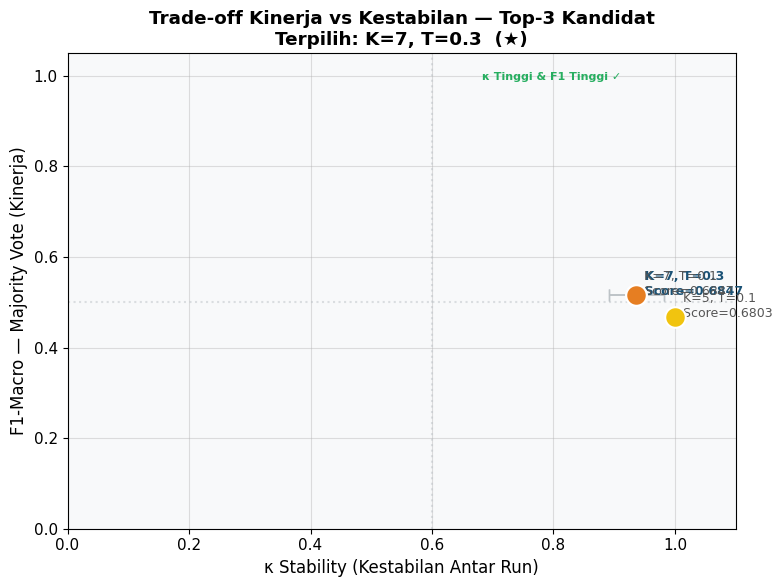

✔ Plot disimpan: T4_scatter_kinerja_vs_stabilitas.png


In [7]:
# =============================================================================
# TAHAP 4: SELEKSI FINAL — Skor Gabungan F1×0.6 + κ×0.4
# =============================================================================
print("\n" + "═" * 65)
print(f"TAHAP 4 — SELEKSI FINAL")
print(f"  Skor Gabungan = F1-Macro (Majority Vote) × {W_F1M} + κ Stability × {W_KAPPA}")
print(f"  → Konfigurasi skor tertinggi = KONFIGURASI FINAL")
print("═" * 65)
 
seleksi_rows = []
for cfg, data in all_combo_stability.items():
    mv_preds   = majority_vote(data["all_preds"])
    mv_metrics = compute_metrics(GROUND_TRUTH, mv_preds)
    combined   = W_F1M * mv_metrics["f1_m"] + W_KAPPA * data["kappa_stab_mean"]
    seleksi_rows.append({
        "config"          : cfg,
        "top_k"           : data["top_k"],
        "temperature"     : data["temperature"],
        "rank_ablasi"     : data["rank_ablasi"],
        "f1_m_mv"         : mv_metrics["f1_m"],
        "f1_w_mv"         : mv_metrics["f1_w"],
        "accuracy_mv"     : mv_metrics["accuracy"],
        "kappa_stab_mean" : data["kappa_stab_mean"],
        "kappa_stab_std"  : data["kappa_stab_std"],
        "combined_score"  : round(combined, 4),
        "mv_preds"        : mv_preds,
        "all_preds"       : data["all_preds"],
    })
 
seleksi_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("mv_preds", "all_preds")} for r in seleksi_rows]
).sort_values("combined_score", ascending=False).reset_index(drop=True)
 
print("\nRINGKASAN SELEKSI:")
print(seleksi_df[["config", "f1_m_mv", "kappa_stab_mean",
                   "kappa_stab_std", "combined_score"]].to_string(index=False))
 
best_row = seleksi_df.iloc[0]
BEST_K   = int(best_row["top_k"])
BEST_T   = float(best_row["temperature"])
BEST_CFG = best_row["config"]
 
print(f"\n  ┌{'─'*55}┐")
print(f"  │  KONFIGURASI FINAL TERPILIH                           │")
print(f"  │  {BEST_CFG:<53}│")
print(f"  │  F1-Macro (MV {N_STABILITY_RUNS}x) = {best_row['f1_m_mv']:.4f}                       │")
print(f"  │  κ Stability         = {best_row['kappa_stab_mean']:.4f} ± {best_row['kappa_stab_std']:.4f}          │")
print(f"  │  Skor Gabungan       = {best_row['combined_score']:.4f}                       │")
print(f"  └{'─'*55}┘")
 
# ── Scatter: kinerja vs kestabilan ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for i, r in enumerate(seleksi_rows):
    color  = "#2ecc71" if r["config"] == BEST_CFG else top3_colors[i]
    ax.scatter(r["kappa_stab_mean"], r["f1_m_mv"],
               s=220, color=color, zorder=5, edgecolors="white", lw=1.5)
    ax.errorbar(r["kappa_stab_mean"], r["f1_m_mv"],
                xerr=r["kappa_stab_std"], fmt="none",
                ecolor="#bdc3c7", capsize=4, lw=1.2)
    ax.annotate(
        f"  {r['config']}\n  Score={r['combined_score']:.4f}",
        (r["kappa_stab_mean"], r["f1_m_mv"]),
        fontsize=9,
        color="#1a5276" if r["config"] == BEST_CFG else "#555",
        fontweight="bold" if r["config"] == BEST_CFG else "normal",
    )
 
ax.set_xlabel("κ Stability (Kestabilan Antar Run)", fontsize=12)
ax.set_ylabel("F1-Macro — Majority Vote (Kinerja)", fontsize=12)
ax.set_title(
    f"Trade-off Kinerja vs Kestabilan — Top-{TOP_N_KANDIDAT} Kandidat\n"
    f"Terpilih: {BEST_CFG}  (★)",
    fontweight="bold"
)
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.05)
# Kuadran guide
ax.axvline(0.6, color="#bdc3c7", ls=":", alpha=0.5)
ax.axhline(np.mean([r["f1_m_mv"] for r in seleksi_rows]),
           color="#bdc3c7", ls=":", alpha=0.5)
ax.text(0.62, 0.96, "κ Tinggi & F1 Tinggi ✓",
        transform=ax.transAxes, fontsize=8, color="#27ae60",
        va="top", fontweight="bold")
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/T4_scatter_kinerja_vs_stabilitas.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✔ Plot disimpan: T4_scatter_kinerja_vs_stabilitas.png")
 

In [8]:
# =============================================================================
# TAHAP 5: UJI KESTABILAN FINAL — 5x run konfigurasi terpilih
# =============================================================================
print("\n" + "═" * 65)
print(f"TAHAP 5 — UJI KESTABILAN FINAL: {N_FINAL_RUNS}x run")
print(f"  Konfigurasi : {BEST_CFG}")
print(f"  Tujuan      : κ Reliability (prediksi vs ground truth) +")
print(f"                κ Stability   (konsistensi pairwise antar run)")
print(f"  Total prediksi: {N_FINAL_RUNS} × {N_TEST} = {N_FINAL_RUNS * N_TEST}")
print("═" * 65)
 
final_all_preds = []
final_logs      = []
 
for run_n in range(1, N_FINAL_RUNS + 1):
    print(f"\n  ── Run {run_n}/{N_FINAL_RUNS} ──")
    preds = run_single(BEST_K, BEST_T, tokenizer, llm_model,
                       run_id=f"final_r{run_n}")
    final_all_preds.append(preds)
    m = compute_metrics(GROUND_TRUTH, preds)
    for i, (pred, true) in enumerate(zip(preds, GROUND_TRUTH)):
        final_logs.append({
            "run"       : run_n, "top_k": BEST_K, "temperature": BEST_T,
            "test_idx"  : i, "true_label": true, "pred_label": pred,
            "correct"   : pred == true,
        })
    print(f"  ✔ Acc={m['accuracy']:.4f}  F1-M={m['f1_m']:.4f}  F1-W={m['f1_w']:.4f}")
 
# Majority vote final
final_preds    = majority_vote(final_all_preds)
mv_final       = compute_metrics(GROUND_TRUTH, final_preds)
 
# κ Reliability (prediksi final vs ground truth)
kappa_rel      = cohen_kappa_score(GROUND_TRUTH, final_preds)
 
# κ Stability pairwise (antar run)
kappa_pairs_val = []
kappa_pairs_lbl = []
print(f"\nCohen's Kappa Stability (pairwise {N_FINAL_RUNS} run):")
for r1, r2 in combinations(range(N_FINAL_RUNS), 2):
    k   = cohen_kappa_score(final_all_preds[r1], final_all_preds[r2])
    lbl = f"R{r1+1}–R{r2+1}"
    kappa_pairs_val.append(k)
    kappa_pairs_lbl.append(lbl)
    print(f"  {lbl}: κ = {k:.4f}  ({interpret_kappa(k)})")
 
kappa_stab_mean = np.mean(kappa_pairs_val)
kappa_stab_std  = np.std(kappa_pairs_val)
 
print(f"\n  κ Stability (rata-rata) : {kappa_stab_mean:.4f} ± {kappa_stab_std:.4f}  "
      f"({interpret_kappa(kappa_stab_mean)})")
print(f"  κ Reliability           : {kappa_rel:.4f}  ({interpret_kappa(kappa_rel)})")
 
# Metrik per run
final_run_rows = []
for r_idx, preds in enumerate(final_all_preds):
    m = compute_metrics(GROUND_TRUTH, preds)
    final_run_rows.append({"Run": r_idx + 1, **m})
final_run_df = pd.DataFrame(final_run_rows)
 
print(f"\nMetrik per Run:")
print(final_run_df[["Run", "accuracy", "f1_m", "f1_w",
                     "precision_m", "recall_m"]].to_string(index=False))
print(f"\nRata-rata ± Std:")
for col, key in [("Accuracy", "accuracy"), ("F1-Macro", "f1_m"), ("F1-Weighted", "f1_w")]:
    print(f"  {col:<14}: {final_run_df[key].mean():.4f} ± {final_run_df[key].std():.4f}")
 
# Classification report
labels_in_test = sorted(set(GROUND_TRUTH))
rpt_str  = classification_report(GROUND_TRUTH, final_preds,
                                  labels=labels_in_test, zero_division=0)
rpt_dict = classification_report(GROUND_TRUTH, final_preds,
                                  labels=labels_in_test, zero_division=0,
                                  output_dict=True)
print(f"\nClassification Report (Majority Vote, {N_FINAL_RUNS} Run):")
print(rpt_str)


═════════════════════════════════════════════════════════════════
TAHAP 5 — UJI KESTABILAN FINAL: 5x run
  Konfigurasi : K=7, T=0.3
  Tujuan      : κ Reliability (prediksi vs ground truth) +
                κ Stability   (konsistensi pairwise antar run)
  Total prediksi: 5 × 71 = 355
═════════════════════════════════════════════════════════════════

  ── Run 1/5 ──


  K=7 T=0.3 [final_r1]: 100%|███████████| 71/71 [02:23<00:00,  2.02s/it]


  ✔ Acc=0.9014  F1-M=0.4778  F1-W=0.8766

  ── Run 2/5 ──


  K=7 T=0.3 [final_r2]: 100%|███████████| 71/71 [02:19<00:00,  1.96s/it]


  ✔ Acc=0.9014  F1-M=0.4778  F1-W=0.8766

  ── Run 3/5 ──


...

  ✔ Acc=0.9014  F1-M=0.4778  F1-W=0.8766

  ── Run 4/5 ──


  K=7 T=0.3 [final_r4]: 100%|███████████| 71/71 [02:26<00:00,  2.06s/it]


  ✔ Acc=0.9014  F1-M=0.4503  F1-W=0.8774

  ── Run 5/5 ──


  K=7 T=0.3 [final_r5]: 100%|███████████| 71/71 [02:20<00:00,  1.98s/it]

  ✔ Acc=0.9014  F1-M=0.4778  F1-W=0.8766

Cohen's Kappa Stability (pairwise 5 run):
  R1–R2: κ = 1.0000  (Sangat Kuat)
  R1–R3: κ = 1.0000  (Sangat Kuat)
  R1–R4: κ = 0.9043  (Sangat Kuat)
  R1–R5: κ = 1.0000  (Sangat Kuat)
  R2–R3: κ = 1.0000  (Sangat Kuat)
  R2–R4: κ = 0.9043  (Sangat Kuat)
  R2–R5: κ = 1.0000  (Sangat Kuat)
  R3–R4: κ = 0.9043  (Sangat Kuat)
  R3–R5: κ = 1.0000  (Sangat Kuat)
  R4–R5: κ = 0.9043  (Sangat Kuat)

  κ Stability (rata-rata) : 0.9617 ± 0.0469  (Sangat Kuat)
  κ Reliability           : 0.5055  (Sedang)

Metrik per Run:
 Run  accuracy   f1_m   f1_w  precision_m  recall_m
   1    0.9014 0.4778 0.8766       0.5584    0.4619
   2    0.9014 0.4778 0.8766       0.5584    0.4619
   3    0.9014 0.4778 0.8766       0.5584    0.4619
   4    0.9014 0.4503 0.8774       0.5128    0.4619
   5    0.9014 0.4778 0.8766       0.5584    0.4619

Rata-rata ± Std:
  Accuracy      : 0.9014 ± 0.0000
  F1-Macro      : 0.4723 ± 0.0123
  F1-Weighted   : 0.8768 ± 0.0004

Classificat


─────────────────────────────────────────────────────────────────
TAHAP 5: VISUALISASI FINAL & EKSPOR
─────────────────────────────────────────────────────────────────


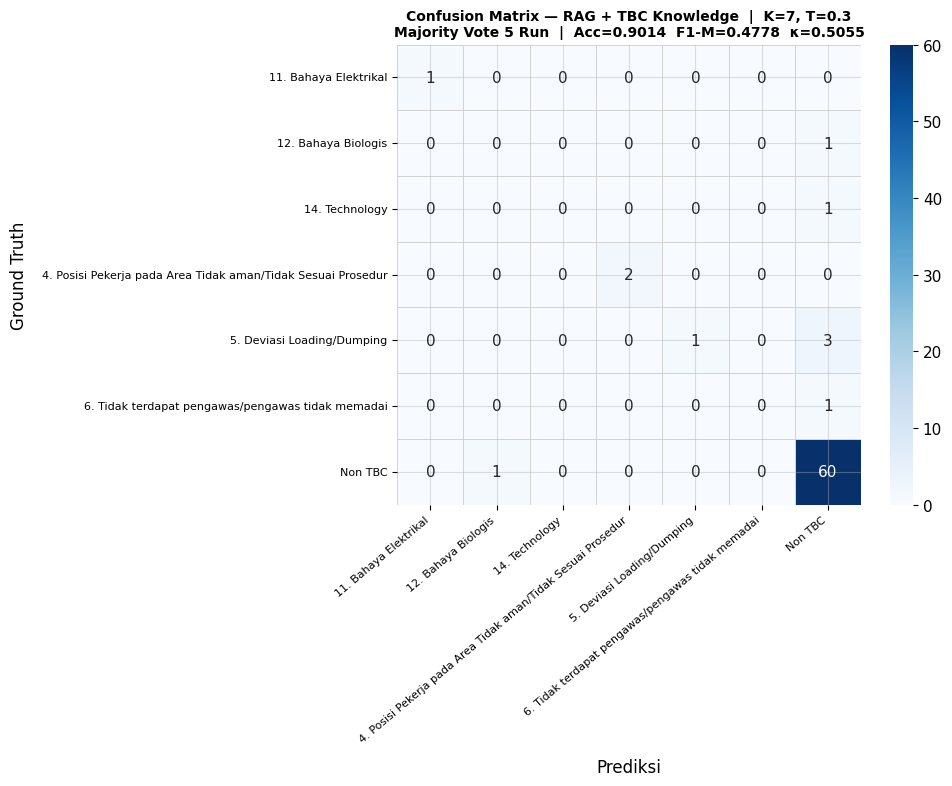

✔ T5_confusion_matrix_final.png


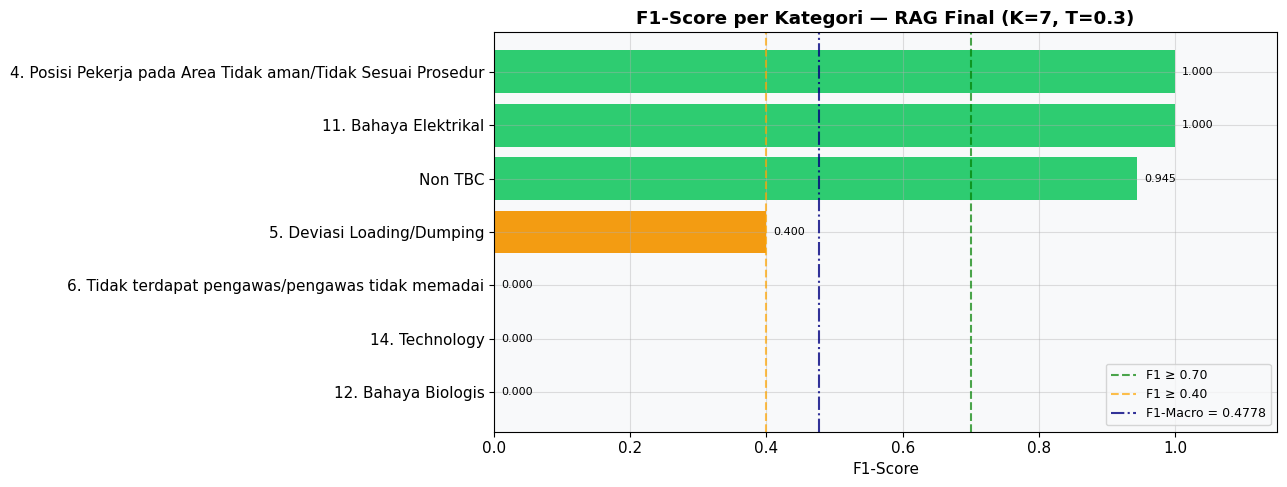

✔ T5_f1_per_kelas.png


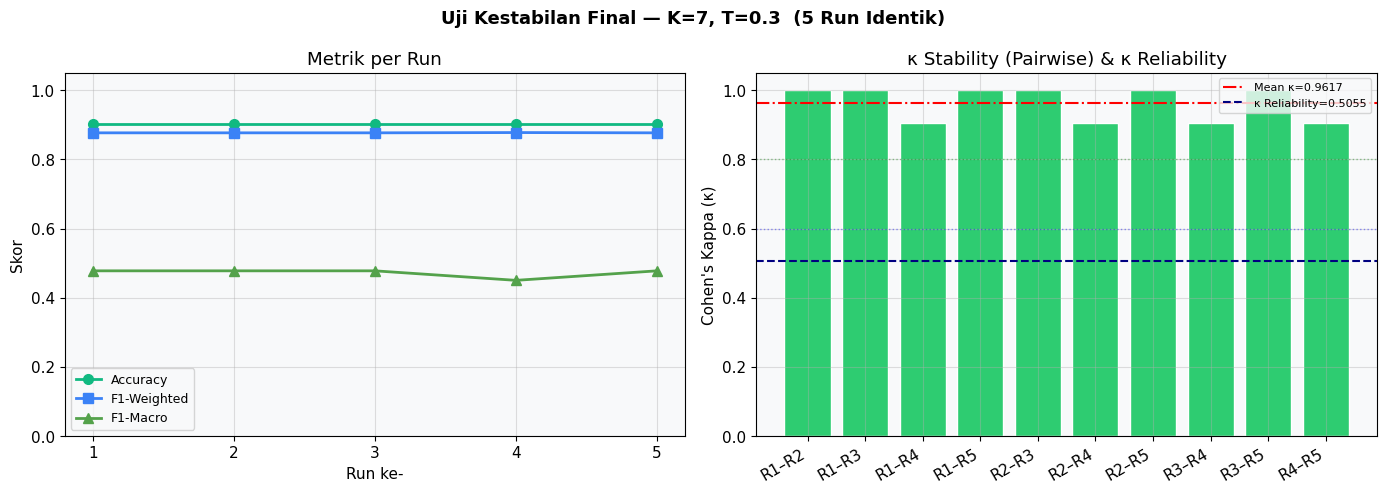

✔ T5_kappa_final.png
✔ RAG_detail_per_run.xlsx
✔ RAG_hasil_prediksi.xlsx / .csv
✔ RAG_classification_report.xlsx
✔ ABLASI_grid_semua_kombinasi.xlsx
✔ STABILITY_top3_seleksi.xlsx
✔ RAG_summary.json


In [10]:
# =============================================================================
# TAHAP 7: VISUALISASI FINAL & EKSPOR
# =============================================================================
print("\n" + "─" * 65)
print("TAHAP 5: VISUALISASI FINAL & EKSPOR")
print("─" * 65)
 
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(GROUND_TRUTH, final_preds, labels=labels_in_test)
fig, ax = plt.subplots(figsize=(max(10, len(labels_in_test) + 2),
                                max(8,  len(labels_in_test))))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_in_test, yticklabels=labels_in_test,
            linewidths=0.5, linecolor="lightgray", ax=ax)
ax.set_xlabel("Prediksi", fontsize=12, labelpad=10)
ax.set_ylabel("Ground Truth", fontsize=12, labelpad=10)
ax.set_title(
    f"Confusion Matrix — RAG + TBC Knowledge  |  {BEST_CFG}\n"
    f"Majority Vote {N_FINAL_RUNS} Run  |  "
    f"Acc={mv_final['accuracy']:.4f}  F1-M={mv_final['f1_m']:.4f}  "
    f"κ={kappa_rel:.4f}",
    fontsize=10, fontweight="bold"
)
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/T5_confusion_matrix_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ T5_confusion_matrix_final.png")
 
# ── F1 per kelas ──────────────────────────────────────────────────────────────
cls_f1 = {k: v["f1-score"] for k, v in rpt_dict.items()
          if k not in ["accuracy", "macro avg", "weighted avg"]}
sc     = sorted(cls_f1, key=lambda x: cls_f1[x])
bc     = [("#2ecc71" if cls_f1[c] >= 0.70 else
           "#f39c12" if cls_f1[c] >= 0.40 else "#e74c3c") for c in sc]
 
fig, ax = plt.subplots(figsize=(13, max(5, len(sc) * 0.55)))
bars = ax.barh(sc, [cls_f1[c] for c in sc], color=bc)
ax.axvline(0.70, color="green",  ls="--", alpha=0.7, label="F1 ≥ 0.70")
ax.axvline(0.40, color="orange", ls="--", alpha=0.7, label="F1 ≥ 0.40")
ax.axvline(mv_final["f1_m"], color="navy", ls="-.", alpha=0.8,
           label=f"F1-Macro = {mv_final['f1_m']:.4f}")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
            f"{w:.3f}", va="center", fontsize=8)
ax.set_xlabel("F1-Score")
ax.set_title(f"F1-Score per Kategori — RAG Final ({BEST_CFG})", fontweight="bold")
ax.set_xlim(0, 1.15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/T5_f1_per_kelas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ T5_f1_per_kelas.png")
 
# ── Metrik per run + κ chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Uji Kestabilan Final — {BEST_CFG}  ({N_FINAL_RUNS} Run Identik)",
             fontsize=13, fontweight="bold")
 
# Fallback colors if they were not defined earlier in the notebook
COLOR_ACC = globals().get("COLOR_ACC", "#4C78A8")
COLOR_F1W = globals().get("COLOR_F1W", "#F58518")
COLOR_F1M = globals().get("COLOR_F1M", "#54A24B")

for col, color, marker, label in [
    ("accuracy", COLOR_ACC, "o", "Accuracy"),
    ("f1_w",     COLOR_F1W, "s", "F1-Weighted"),
    ("f1_m",     COLOR_F1M, "^", "F1-Macro"),
]:
    axes[0].plot(
        final_run_df["Run"],
        final_run_df[col],
        marker=marker,
        lw=2,
        color=color,
        ms=7,
        label=label,
    )
axes[0].set_xlabel("Run ke-")
axes[0].set_ylabel("Skor")
axes[0].set_title("Metrik per Run")
axes[0].set_xticks(final_run_df["Run"])
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)
 
kappa_bar_colors = [
    ("#2ecc71" if k >= 0.60 else "#f39c12" if k >= 0.40 else "#e74c3c")
    for k in kappa_pairs_val
]
axes[1].bar(kappa_pairs_lbl, kappa_pairs_val, color=kappa_bar_colors, edgecolor="white")
axes[1].axhline(kappa_stab_mean, color="red", ls="-.",
                lw=1.5, label=f"Mean κ={kappa_stab_mean:.4f}")
axes[1].axhline(kappa_rel, color="navy", ls="--",
                lw=1.5, label=f"κ Reliability={kappa_rel:.4f}")
for th, col, lbl in [(0.80, "green", "0.80"), (0.60, "blue", "0.60")]:
    axes[1].axhline(th, color=col, ls=":", alpha=0.4, lw=1)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Cohen's Kappa (κ)")
axes[1].set_title("κ Stability (Pairwise) & κ Reliability")
axes[1].legend(fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/T5_kappa_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ T5_kappa_final.png")
 
# ── Simpan data ───────────────────────────────────────────────────────────────
# Log per run
pd.DataFrame(final_logs).to_excel(f"{OUTPUT_DIR}/RAG_detail_per_run.xlsx", index=False)
print("✔ RAG_detail_per_run.xlsx")
 
# Hasil prediksi final
result_df = df_test[[COL_LABEL, COL_TEXT]].copy()
result_df.columns = ["true_label", "teks_final"]
result_df["pred_final"] = final_preds
result_df["correct"]    = [p == t for p, t in zip(final_preds, GROUND_TRUTH)]
for r_idx, preds in enumerate(final_all_preds):
    result_df[f"pred_run{r_idx+1}"] = preds
result_df.to_excel(f"{OUTPUT_DIR}/RAG_hasil_prediksi.xlsx", index=False)
result_df.to_csv( f"{OUTPUT_DIR}/RAG_hasil_prediksi.csv",   index=False)
print("✔ RAG_hasil_prediksi.xlsx / .csv")
 
# Classification report
rpt_rows = [
    {"Label": k, "Precision": round(v["precision"], 4),
     "Recall": round(v["recall"], 4), "F1-Score": round(v["f1-score"], 4),
     "Support": int(v["support"])}
    for k, v in rpt_dict.items() if isinstance(v, dict)
]
pd.DataFrame(rpt_rows).to_excel(f"{OUTPUT_DIR}/RAG_classification_report.xlsx", index=False)
print("✔ RAG_classification_report.xlsx")
 
# Ablasi grid hasil
grid_df.to_excel(f"{OUTPUT_DIR}/ABLASI_grid_semua_kombinasi.xlsx", index=False)
print("✔ ABLASI_grid_semua_kombinasi.xlsx")
 
# Stability test hasil
stab_export = seleksi_df[["config", "top_k", "temperature", "rank_ablasi",
                            "f1_m_mv", "f1_w_mv", "accuracy_mv",
                            "kappa_stab_mean", "kappa_stab_std",
                            "combined_score"]]
stab_export.to_excel(f"{OUTPUT_DIR}/STABILITY_top3_seleksi.xlsx", index=False)
print("✔ STABILITY_top3_seleksi.xlsx")
 
# Summary JSON lengkap
summary = {
    "skenario"              : "RAG + TBC Knowledge Injection (Berau Coal) — Pendekatan C",
    "model_embed"           : EMBED_MODEL,
    "model_llm"             : LLM_MODEL,
    "collection_name"       : COLLECTION_NAME,
    "knowledge_file"        : KNOWLEDGE_FILE,
    "tbc_docs_injected"     : 28,
 
    "ofat_sensitivity"      : {
        "dijalankan"        : RUN_OFAT,
        "best_k_ofat"       : BEST_K_OFAT,
        "best_t_ofat"       : BEST_T_OFAT,
        "catatan"           : "Opsional — tidak mempengaruhi alur utama Pendekatan C",
    },
 
    "tahap2_ablasi_grid"    : {
        "total_kombinasi"   : len(KANDIDAT_K) * len(KANDIDAT_T),
        "kandidat_k"        : KANDIDAT_K,
        "kandidat_t"        : KANDIDAT_T,
        "top3"              : top3_df[["top_k","temperature","f1_m"]].to_dict("records"),
    },
 
    "tahap3_stability_test" : {
        "n_runs_per_kandidat": N_STABILITY_RUNS,
        "top_n_kandidat"    : TOP_N_KANDIDAT,
        "total_prediksi"    : TOP_N_KANDIDAT * N_STABILITY_RUNS * N_TEST,
        "kandidat"          : [
            {"config": cfg, "f1m_mean": d["f1m_mean"],
             "kappa_stab_mean": d["kappa_stab_mean"],
             "kappa_stab_std" : d["kappa_stab_std"]}
            for cfg, d in all_combo_stability.items()
        ],
    },
 
    "tahap4_seleksi_final"  : {
        "bobot_f1m"         : W_F1M,
        "bobot_kappa"       : W_KAPPA,
        "formula"           : f"combined = F1-Macro × {W_F1M} + κ Stability × {W_KAPPA}",
        "konfigurasi_final" : BEST_CFG,
        "top_k"             : BEST_K,
        "temperature"       : BEST_T,
        "tabel_seleksi"     : seleksi_df[["config","f1_m_mv","kappa_stab_mean",
                                           "combined_score"]].to_dict("records"),
    },
 
    "tahap5_kestabilan_final": {
        "n_runs"            : N_FINAL_RUNS,
        "per_run_f1_macro"  : final_run_df["f1_m"].tolist(),
        "per_run_accuracy"  : final_run_df["accuracy"].tolist(),
        "mean_f1_macro"     : round(final_run_df["f1_m"].mean(), 4),
        "std_f1_macro"      : round(final_run_df["f1_m"].std(),  4),
    },
 
    "metrik_final"          : {
        "accuracy"          : mv_final["accuracy"],
        "precision_w"       : mv_final["precision_w"],
        "precision_m"       : mv_final["precision_m"],
        "recall_w"          : mv_final["recall_w"],
        "recall_m"          : mv_final["recall_m"],
        "f1_weighted"       : mv_final["f1_w"],
        "f1_macro"          : mv_final["f1_m"],
        "kappa_reliability" : round(kappa_rel, 4),
        "kappa_rel_interp"  : interpret_kappa(kappa_rel),
        "kappa_stab_mean"   : round(kappa_stab_mean, 4),
        "kappa_stab_std"    : round(kappa_stab_std,  4),
        "kappa_stab_interp" : interpret_kappa(kappa_stab_mean),
        "kappa_pairs"       : dict(zip(kappa_pairs_lbl,
                                       [round(k, 4) for k in kappa_pairs_val])),
    },
 
    "efisiensi_pendekatan_c": {
        "tahap2_prediksi"   : 15 * N_TEST,
        "tahap3_prediksi"   : TOP_N_KANDIDAT * N_STABILITY_RUNS * N_TEST,
        "tahap5_prediksi"   : N_FINAL_RUNS * N_TEST,
        "total_prediksi"    : 15*N_TEST + TOP_N_KANDIDAT*N_STABILITY_RUNS*N_TEST + N_FINAL_RUNS*N_TEST,
        "pendekatan_b"      : 15 * 5 * N_TEST,
        "penghematan_pct"   : round((1 - (15*N_TEST + TOP_N_KANDIDAT*N_STABILITY_RUNS*N_TEST + N_FINAL_RUNS*N_TEST)
                                    / (15*5*N_TEST)) * 100, 1),
    },
 
    "timestamp" : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}
 
with open(f"{OUTPUT_DIR}/RAG_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print("✔ RAG_summary.json")
 

In [12]:
# =============================================================================
# RINGKASAN AKHIR
# =============================================================================
print(f"""
{"=" * 65}
PIPELINE RAG — PENDEKATAN C — SELESAI
{"=" * 65}
 
  [ARSITEKTUR RAG]
  Embedding  : {EMBED_MODEL}
  LLM        : {LLM_MODEL}
  ChromaDB   : {COLLECTION_NAME} ({collection.count()} dokumen total)
    ├─ KB data historis (example)     : {len(df_kb)} dokumen
    └─ TBC knowledge Berau Coal       : 28 dokumen (14 def + 14 kw_sev)
 
  [KONFIGURASI FINAL TERPILIH]
  TOP_K       = {BEST_K}
  Temperature = {BEST_T}
  Dipilih via : Grid ablasi (Tahap 2) + Stability (Tahap 3)
                + Skor gabungan F1×{W_F1M} + κ×{W_KAPPA} (Tahap 4)
 
  [METRIK FINAL — Majority Vote {N_FINAL_RUNS} Run (Tahap 5)]
  Accuracy       : {mv_final['accuracy']:.4f}
  Precision W/M  : {mv_final['precision_w']:.4f} / {mv_final['precision_m']:.4f}
  Recall    W/M  : {mv_final['recall_w']:.4f} / {mv_final['recall_m']:.4f}
  F1-Score  W/M  : {mv_final['f1_w']:.4f} / {mv_final['f1_m']:.4f}
  κ Reliability  : {kappa_rel:.4f}  ({interpret_kappa(kappa_rel)})
  κ Stability    : {kappa_stab_mean:.4f} ± {kappa_stab_std:.4f}  ({interpret_kappa(kappa_stab_mean)})
 
  [EFISIENSI PENDEKATAN C vs B]
  Tahap 2 grid   : 15 × 1 × {N_TEST} = {15 * N_TEST} prediksi
  Tahap 3 stab   :  {TOP_N_KANDIDAT} × {N_STABILITY_RUNS} × {N_TEST} = {TOP_N_KANDIDAT * N_STABILITY_RUNS * N_TEST} prediksi
  Tahap 5 final  :  1 × {N_FINAL_RUNS} × {N_TEST} = {N_FINAL_RUNS * N_TEST} prediksi
  Total C        : {15*N_TEST + TOP_N_KANDIDAT*N_STABILITY_RUNS*N_TEST + N_FINAL_RUNS*N_TEST} prediksi
  Pendekatan B   : {15*5*N_TEST} prediksi
  Penghematan    : ~{round((1-(15*N_TEST+TOP_N_KANDIDAT*N_STABILITY_RUNS*N_TEST+N_FINAL_RUNS*N_TEST)/(15*5*N_TEST))*100,0):.0f}% lebih efisien
 
  [OUTPUT → folder '{OUTPUT_DIR}/']
  Visualisasi:
    T2_ablasi_grid_heatmap_top3.png    ← heatmap F1 + Top-3
    T3_stability_top3_per_run.png      ← per-run line chart
    T4_scatter_kinerja_vs_stabilitas.png ← kinerja vs κ
    T5_confusion_matrix_final.png      ← confusion matrix MV
    T5_f1_per_kelas.png                ← F1 per kategori
    T5_kappa_final.png                 ← κ Stability pairwise
    [OFAT_ablasi_sensitivity.png]      ← hanya jika RUN_OFAT=True
  Data:
    ABLASI_grid_semua_kombinasi.xlsx   ← 15 kombinasi K×T
    STABILITY_top3_seleksi.xlsx        ← skor gabungan seleksi
    RAG_detail_per_run.xlsx            ← log prediksi per run
    RAG_hasil_prediksi.xlsx / .csv     ← prediksi final + MV
    RAG_classification_report.xlsx     ← precision/recall/F1
    RAG_summary.json                   ← semua ringkasan lengkap
    run_cache.json                     ← cache semua run
 
{"=" * 65}
""")


PIPELINE RAG — PENDEKATAN C — SELESAI

  [ARSITEKTUR RAG]
  Embedding  : all-MiniLM-L6-v2
  LLM        : google/flan-t5-large
  ChromaDB   : kb_rag_enriched (631 dokumen total)
    ├─ KB data historis (example)     : 631 dokumen
    └─ TBC knowledge Berau Coal       : 28 dokumen (14 def + 14 kw_sev)

  [KONFIGURASI FINAL TERPILIH]
  TOP_K       = 7
  Temperature = 0.3
  Dipilih via : Grid ablasi (Tahap 2) + Stability (Tahap 3)
                + Skor gabungan F1×0.6 + κ×0.4 (Tahap 4)

  [METRIK FINAL — Majority Vote 5 Run (Tahap 5)]
  Accuracy       : 0.9014
  Precision W/M  : 0.8796 / 0.5584
  Recall    W/M  : 0.9014 / 0.4619
  F1-Score  W/M  : 0.8766 / 0.4778
  κ Reliability  : 0.5055  (Sedang)
  κ Stability    : 0.9617 ± 0.0469  (Sangat Kuat)

  [EFISIENSI PENDEKATAN C vs B]
  Tahap 2 grid   : 15 × 1 × 71 = 1065 prediksi
  Tahap 3 stab   :  3 × 3 × 71 = 639 prediksi
  Tahap 5 final  :  1 × 5 × 71 = 355 prediksi
  Total C        : 2059 prediksi
  Pendekatan B   : 5325 prediksi
  Peng